# 01. Regression discontinuity at the promised delivery date

## What we're testing and why

Every order shows the customer a promised delivery date. We want to know whether **breaking that promise** *causes* worse reviews, or whether late orders just happen to be the kind of orders that get bad reviews anyway (far away, heavy, cheap sellers).

The idea: compare orders that arrived **on the promised day** (`days_late = 0`) with orders that arrived **one day after** (`days_late = 1`). Those orders are almost identical in everything except that one group broke the promise. If reviews drop sharply exactly at the promise, and nothing else jumps there, the drop is caused by lateness.

The plan is pre-registered in `analysis_plan.md` (Test 1). Every check below is in that plan.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf
from src.db import run_query

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from rdrobust import rdrobust
from rddensity import rddensity

In [2]:
df = run_query("SELECT * FROM causal.rdd_sample")

df["days_late"] = df["days_late"].astype(float)
df["price"] = df["price"].astype(float)
df["freight"] = df["freight"].astype(float)
df["weight_g"] = df["weight_g"].astype(float)
df["distance_km"] = df["distance_km"].astype(float)
df["promised_days"] = df["promised_days"].astype(float)

print("Orders in RDD sample:", len(df))
df.head()

Orders in RDD sample: 95824


,order_id,days_late,late,review_score,low_review,price,freight,weight_g,distance_km,promised_days,answered_after_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,-9.0000,0,5,0,58.9000,13.2900,650.0000,301.5047,16.0000,1
1,00018f77f2f0320c557190d7a144bdd3,-3.0000,0,4,0,239.9000,19.9300,"30,000.0000",585.5639,19.0000,1
2,000229ec398224ef6ca0657da4fc703e,-14.0000,0,5,0,199.0000,17.8700,"3,050.0000",312.3435,22.0000,1
3,00024acbcdf0a6daa1e931b038114c75,-6.0000,0,4,0,12.9900,12.7900,200.0000,293.1684,12.0000,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,-16.0000,0,5,0,199.9000,18.1400,"3,750.0000",646.1635,41.0000,1


In [3]:
near = df[(df["days_late"] >= -20) & (df["days_late"] <= 20)]

bins = near.groupby("days_late").agg(
    n_orders=("order_id", "count"),
    avg_review=("review_score", "mean"),
    low_review_share=("low_review", "mean"),
).reset_index()

bins.to_csv("../outputs/tables/rdd_bins.csv", index=False)
bins

,days_late,n_orders,avg_review,low_review_share
0,-20.0000,2949,4.3666,0.0793
1,-19.0000,2693,4.3587,0.0787
2,-18.0000,3116,4.3309,0.0886
3,-17.0000,3398,4.3367,0.0856
4,-16.0000,3888,4.3336,0.0815
5,-15.0000,5318,4.3481,0.0842
6,-14.0000,7090,4.3286,0.0913
7,-13.0000,5926,4.3380,0.0822
8,-12.0000,4526,4.3109,0.0884
9,-11.0000,4592,4.3014,0.0906


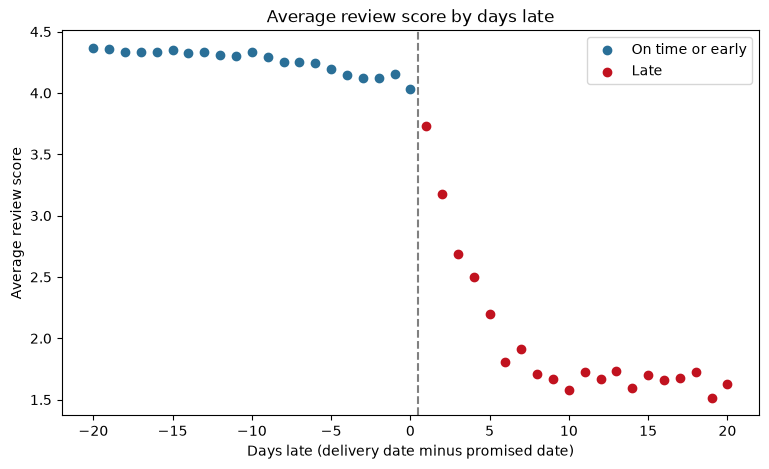

In [4]:
left = bins[bins["days_late"] <= 0]
right = bins[bins["days_late"] >= 1]

plt.figure(figsize=(9, 5))
plt.scatter(left["days_late"], left["avg_review"], color="#2a6f97", label="On time or early")
plt.scatter(right["days_late"], right["avg_review"], color="#c1121f", label="Late")
plt.axvline(0.5, color="grey", linestyle="--")
plt.xlabel("Days late (delivery date minus promised date)")
plt.ylabel("Average review score")
plt.title("Average review score by days late")
plt.legend()
plt.savefig("../outputs/figures/rdd_review_by_days_late.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
def run_rd(data, outcome, h=None):
    d = data.dropna(subset=[outcome, "days_late"])
    if h is None:
        result = rdrobust(d[outcome], d["days_late"], c=0.5, p=1, kernel="triangular", bwselect="mserd")
    else:
        result = rdrobust(d[outcome], d["days_late"], c=0.5, p=1, kernel="triangular", h=h)

    row = {}
    row["outcome"] = outcome
    row["estimate"] = result.coef.loc["Conventional", "Coeff"]
    row["bias_corrected_estimate"] = result.coef.loc["Robust", "Coeff"]
    row["robust_se"] = result.se.loc["Robust", "Std. Err."]
    row["robust_ci_low"] = result.ci.loc["Robust", "CI Lower"]
    row["robust_ci_high"] = result.ci.loc["Robust", "CI Upper"]
    row["robust_p"] = result.pv.loc["Robust", "P>|z|"]
    row["h"] = result.bws.loc["h", "left"]
    row["n_left"] = result.N_h[0]
    row["n_right"] = result.N_h[1]
    return row

In [6]:
main_rows = []
for outcome in ["review_score", "low_review"]:
    row = run_rd(df, outcome)
    row["test"] = "main"
    main_rows.append(row)

main = pd.DataFrame(main_rows)
main

Mass points detected in the running variable.


Mass points detected in the running variable.


,outcome,estimate,bias_corrected_estimate,robust_se,robust_ci_low,robust_ci_high,robust_p,h,n_left,n_right,test
0,review_score,-0.0770,-0.0241,0.0729,-0.1670,0.1188,0.7409,3.8216,5985,2288,main
1,low_review,0.0019,-0.0135,0.0209,-0.0544,0.0274,0.5182,3.7389,5985,2288,main


In [7]:
window = df[(df["days_late"] >= -7) & (df["days_late"] <= 7)].copy()
window["x"] = window["days_late"] - 0.5
window["late_x"] = window["late"] * window["x"]
window["days_late_group"] = window["days_late"].astype(int)

ols_rows = []
for outcome in ["review_score", "low_review"]:
    fit = pf.feols(outcome + " ~ late + x + late_x", data=window, vcov={"CRV1": "days_late_group"})
    t = fit.tidy()
    row = {}
    row["test"] = "ols_window_7_clustered_by_day"
    row["outcome"] = outcome
    row["estimate"] = t.loc["late", "Estimate"]
    row["se"] = t.loc["late", "Std. Error"]
    row["ci_low"] = t.loc["late", "2.5%"]
    row["ci_high"] = t.loc["late", "97.5%"]
    row["p"] = t.loc["late", "Pr(>|t|)"]
    row["n"] = fit._N
    ols_rows.append(row)

ols = pd.DataFrame(ols_rows)
ols

,test,outcome,estimate,se,ci_low,ci_high,p,n
0,ols_window_7_clustered_by_day,review_score,-0.3332,0.1424,-0.6386,-0.0279,0.0346,22114
1,ols_window_7_clustered_by_day,low_review,0.0698,0.0381,-0.0119,0.1515,0.0883,22114


In [8]:
density = rddensity(X=df["days_late"].values, c=0.5)
print(density.test)

counts = df[(df["days_late"] >= -3) & (df["days_late"] <= 3)]["days_late"].value_counts().sort_index()
print(counts)

density_result = pd.DataFrame([{
    "test": "density_rddensity",
    "t_jk": density.test["t_jk"],
    "p_jk": density.test["p_jk"],
    "n_day_0": counts.loc[0.0],
    "n_day_1": counts.loc[1.0],
}])
density_result

t_asy       NaN
t_jk    37.0586
p_asy       NaN
p_jk     0.0000
dtype: float64
days_late
-3.0000    1715
-2.0000    1540
-1.0000    1450
0.0000     1280
1.0000      820
2.0000      536
3.0000      496
Name: count, dtype: int64


,test,t_jk,p_jk,n_day_0,n_day_1
0,density_rddensity,37.0586,0.0000,1280,820


In [9]:
balance_rows = []
for covariate in ["price", "freight", "weight_g", "distance_km", "promised_days"]:
    row = run_rd(df, covariate)
    row["test"] = "covariate_balance"
    balance_rows.append(row)

balance = pd.DataFrame(balance_rows)
balance

Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


,outcome,estimate,bias_corrected_estimate,robust_se,robust_ci_low,robust_ci_high,robust_p,h,n_left,n_right,test
0,price,5.7438,3.3378,6.7495,-9.8909,16.5665,0.6209,11.5719,37130,4688,covariate_balance
1,freight,2.3140,2.0136,0.8286,0.3895,3.6377,0.0151,9.3885,23314,4149,covariate_balance
2,weight_g,442.8243,484.2286,189.9741,111.8862,856.5709,0.0108,14.1089,47578,5046,covariate_balance
3,distance_km,30.6027,21.6401,29.1244,-35.4426,78.7229,0.4575,6.5583,13637,3574,covariate_balance
4,promised_days,2.4382,2.2873,0.3953,1.5125,3.0621,0.0000,5.3743,7888,2722,covariate_balance


In [10]:
donut = df[(df["days_late"] != 0) & (df["days_late"] != 1)]

robust_rows = []
for outcome in ["review_score", "low_review"]:
    h_main = main[main["outcome"] == outcome]["h"].values[0]

    try:
        half = run_rd(df, outcome, h=0.5 * h_main)
    except Exception as error:
        half = {"outcome": outcome, "h": 0.5 * h_main, "note": "could not be estimated: " + str(error)}
    half["test"] = "bandwidth_x0.5"
    robust_rows.append(half)

    try:
        double = run_rd(df, outcome, h=2 * h_main)
    except Exception as error:
        double = {"outcome": outcome, "h": 2 * h_main, "note": "could not be estimated: " + str(error)}
    double["test"] = "bandwidth_x2"
    robust_rows.append(double)

    try:
        hole = run_rd(donut, outcome)
    except Exception as error:
        hole = {"outcome": outcome, "note": "could not be estimated: " + str(error)}
    hole["test"] = "donut_drop_0_and_1"
    robust_rows.append(hole)

robustness = pd.DataFrame(robust_rows)
robustness

Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


Mass points detected in the running variable.


,outcome,estimate,bias_corrected_estimate,robust_se,robust_ci_low,robust_ci_high,robust_p,h,n_left,n_right,test
0,review_score,0.0366,-0.0588,0.0813,-0.2182,0.1005,0.4693,1.9108,2730,1356,bandwidth_x0.5
1,review_score,-0.2560,-0.0419,0.0742,-0.1874,0.1035,0.5722,7.6433,18514,3930,bandwidth_x2
2,review_score,-0.4552,-0.3502,0.1576,-0.6591,-0.0414,0.0262,4.2346,4705,1468,donut_drop_0_and_1
3,low_review,-0.0083,-0.1482,0.0382,-0.2231,-0.0734,0.0001,1.8694,2730,1356,bandwidth_x0.5
4,low_review,0.0453,-0.0108,0.0214,-0.0528,0.0311,0.6135,7.4777,13699,3600,bandwidth_x2
5,low_review,0.0510,0.0162,0.0479,-0.0777,0.1101,0.7356,4.0112,4705,1468,donut_drop_0_and_1


In [11]:
after = df[df["answered_after_delivery"] == 1]
print("Reviews answered after delivery:", len(after), "of", len(df))

mechanism_rows = []
for outcome in ["review_score", "low_review"]:
    row = run_rd(after, outcome)
    row["test"] = "mechanism_answered_after_delivery"
    mechanism_rows.append(row)

mechanism = pd.DataFrame(mechanism_rows)
mechanism

Reviews answered after delivery: 91170 of 95824
Mass points detected in the running variable.


Mass points detected in the running variable.


,outcome,estimate,bias_corrected_estimate,robust_se,robust_ci_low,robust_ci_high,robust_p,h,n_left,n_right,test
0,review_score,-0.2826,-0.2716,0.0704,-0.4095,-0.1336,0.0001,7.0420,13657,1831,mechanism_answered_after_delivery
1,low_review,0.0570,0.0543,0.0197,0.0157,0.0929,0.0059,7.1198,13657,1831,mechanism_answered_after_delivery


In [12]:
rd_results = pd.concat([main, balance, robustness, mechanism])
if "note" not in rd_results.columns:
    rd_results["note"] = ""
rd_results["note"] = rd_results["note"].fillna("")
columns = ["test", "outcome", "estimate", "bias_corrected_estimate", "robust_se", "robust_ci_low", "robust_ci_high", "robust_p", "h", "n_left", "n_right", "note"]
rd_results = rd_results[columns]

rd_results.to_csv("../outputs/tables/test1_rdd_results.csv", index=False)
ols.to_csv("../outputs/tables/test1_rdd_ols_check.csv", index=False)
density_result.to_csv("../outputs/tables/test1_rdd_density.csv", index=False)

with open("../outputs/tables/test1_rdd_results.md", "w") as f:
    f.write("# Test 1: RDD results\n\n")
    f.write(rd_results.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n# OLS check (days_late -7 to 7, SEs clustered by day)\n\n")
    f.write(ols.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n# Density test\n\n")
    f.write(density_result.to_markdown(index=False, floatfmt=".4f"))

rd_results

,test,outcome,estimate,bias_corrected_estimate,robust_se,robust_ci_low,robust_ci_high,robust_p,h,n_left,n_right,note
0,main,review_score,-0.0770,-0.0241,0.0729,-0.1670,0.1188,0.7409,3.8216,5985,2288,
1,main,low_review,0.0019,-0.0135,0.0209,-0.0544,0.0274,0.5182,3.7389,5985,2288,
0,covariate_balance,price,5.7438,3.3378,6.7495,-9.8909,16.5665,0.6209,11.5719,37130,4688,
1,covariate_balance,freight,2.3140,2.0136,0.8286,0.3895,3.6377,0.0151,9.3885,23314,4149,
2,covariate_balance,weight_g,442.8243,484.2286,189.9741,111.8862,856.5709,0.0108,14.1089,47578,5046,
3,covariate_balance,distance_km,30.6027,21.6401,29.1244,-35.4426,78.7229,0.4575,6.5583,13637,3574,
4,covariate_balance,promised_days,2.4382,2.2873,0.3953,1.5125,3.0621,0.0000,5.3743,7888,2722,
0,bandwidth_x0.5,review_score,0.0366,-0.0588,0.0813,-0.2182,0.1005,0.4693,1.9108,2730,1356,
1,bandwidth_x2,review_score,-0.2560,-0.0419,0.0742,-0.1874,0.1035,0.5722,7.6433,18514,3930,
2,donut_drop_0_and_1,review_score,-0.4552,-0.3502,0.1576,-0.6591,-0.0414,0.0262,4.2346,4705,1468,


## What this means for the business

**What the raw data shows.** Average review is 4.03 when an order arrives on the promised day, 3.73 at 1 day late, 3.18 at 2 days, 2.68 at 3 days, and it flattens around 1.6–1.8 after about a week. So the damage **builds over the first week of delay** rather than jumping at the exact promised day.

**Pre-registered RDD result (Test 1).** The formal jump between day 0 and day 1 is **not statistically significant**: −0.08 stars (robust 95% CI −0.17 to +0.12, p = 0.74), and +0.2 pp for a 1–2 star review (p = 0.52). The MSE-optimal bandwidth is only about 4 days, so the estimate rests on just 4 distinct days on the left and 4 on the right.

**Validity checks raise real concerns:**
- **Bunching:** 1,280 orders arrive on the promised day and only 820 one day later (density test p < 0.001). Deliveries seem to be pushed to just make the promise, so orders on the two sides may not be comparable.
- **Covariates jump at the cutoff:** orders just past the promise had longer promises (+2.4 days, p < 0.001), heavier parcels (p = 0.011) and higher freight (p = 0.015). Price and distance don't jump.
- **Robustness:** bandwidth ×0.5 could not be estimated (too few distinct days); ×2 is not significant (p = 0.57); the donut RDD (dropping days 0 and 1) is significant (−0.46 stars, p = 0.026).
- **OLS check (±7 days):** −0.33 stars (p = 0.035), but with only 15 clusters these SEs are unreliable.

**Mechanism check (pre-specified).** Using only reviews answered *after* the parcel arrived, the jump is significant: **−0.28 stars (p < 0.001)** and **+5.7 pp** for a 1–2 star review (p = 0.006). Customers react once they actually experience the delay.

**For the business:** one day late does little harm on its own. The real damage comes from orders 3+ days late. Because of the bunching and the covariate jumps, this RDD **cannot on its own prove** that lateness causes bad reviews. The causal claim rests mainly on Test 2.